# 8.9 Assignment 8: Support Vector Machine (SVM)

Miranda Rasmussen <br>
11/17/2025<br>
IMT 574: Data Science II: Machine Learning<br>
Instructor: Sophin Liu

#### **Overview**
Problem 1 <br>
In this exercise, you will use the Portuguese sea battles data: https://users.stat.ufl.edu/~winner/data/armada.dat. that contains outcomes of naval battles between Portuguese and Dutch/British ships between 1583 and 1663.<br>
**The dataset has the following features:**<br>
Features: Features Explained <br>
Battle: Name of the battle place <br>
Year: Year of the battle <br>
Portuguese ships: Number of Portuguese ships<br>
Dutch ships: Number of Dutch ships <br>
English ships: Number of ships from English side<br>
The ratio of Portuguese to Dutch/British ships	<br>
Spanish Involvement: 1=Yes, 0=No <br>
Portuguese outcome: -1=Defeat, 0=Draw, 1=Victory<br>
##### **Instructions**
1. Use an SVM-based model to predict the Portuguese outcome of the battle from the number of ships involved on all sides and Spanish involvement.
2. Try solving the same problem using two other classifiers that you know.
3. Report and compare their results with those from SVM.

In [12]:
#import and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.set_option('display.max_columns', 30)
random_state = 42

In [13]:
url = "https://users.stat.ufl.edu/~winner/data/armada.dat"
df = pd.read_fwf(url, header=None)
df.columns = [
    "Battle",
    "Year",
    "Portuguese_ships",
    "Dutch_ships",
    "English_ships",
    "Ratio_of_P", #Ratio of Portuguese ships to Dutch and British ships
    "Spanish_invol", #Spanish involvement (1 = Yes and 0 = No
    "P_outcome" #Portuguese outcome (-1 = Deafeat, 0 = Draw, 1 = Victory)
]
df

,Battle,Year,Portuguese_ships,Dutch_ships,English_ships,Ratio_of_P,Spanish_invol,P_outcome
0,Bantam,1601,6,3,0,2.000,0,0
1,Malacca Strait,1606,14,11,0,1.273,0,0
2,Ilha das Naus,1606,6,9,0,0.667,0,-1
3,Pulo Butum,1606,7,9,0,0.778,0,1
4,Surrat,1615,6,0,4,1.500,0,0
5,Ilha das Naus,1615,3,5,0,0.600,0,-1
6,Jask,1620,4,0,4,1.000,0,0
7,Hormuz,1622,6,0,5,1.200,0,-1
8,Mogincoal Shoals,1622,4,4,2,0.667,0,-1
9,Hormuz,1625,8,4,4,1.000,0,0


In [14]:
#Normalize column names to lowercase with underscores
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
print("Columns:", list(df.columns))
df.head()

Columns: ['battle', 'year', 'portuguese_ships', 'dutch_ships', 'english_ships', 'ratio_of_p', 'spanish_invol', 'p_outcome']


,battle,year,portuguese_ships,dutch_ships,english_ships,ratio_of_p,spanish_invol,p_outcome
0,Bantam,1601,6,3,0,2.000,0,0
1,Malacca Strait,1606,14,11,0,1.273,0,0
2,Ilha das Naus,1606,6,9,0,0.667,0,-1
3,Pulo Butum,1606,7,9,0,0.778,0,1
4,Surrat,1615,6,0,4,1.500,0,0


In [15]:
#Select Features
def pick(colnames):
    for c in colnames:
        if c in df.columns:
            return c
    return None

col_port = pick(['portugese_ships','port'])
col_dutch = pick(['dutch_ships','dutch'])
col_english = pick(['english_ships','english'])
col_spanish = pick(['spanish_involvement','spanish','spain_involvement'])
col_outcome = pick(['portuguese_outcome','outcome','result'])

print("Detected columns:")
print("Portuguese ships:", col_port)
print("Dutch ships:", col_dutch)
print("English ships:", col_english)
print("Spanish involvement:", col_spanish)
print("Outcome:", col_outcome)

X = df[[col_port, col_dutch, col_english, col_spanish]].copy()
y = df[col_outcome].copy()

# Drop rows with any missing values in the selected columns
data = pd.concat([X, y], axis=1).dropna()
X = data[[col_port, col_dutch, col_english, col_spanish]]
y = data[col_outcome]

print("\nFinal modeling rows:", X.shape[0])
X.head()

Detected columns:
Portuguese ships: None
Dutch ships: dutch_ships
English ships: english_ships
Spanish involvement: None
Outcome: None


KeyError: '[None] not in index'

Outcome counts (label -> count):
portuguese_outcome
-1    10
 0    13
 1     5
Name: count, dtype: int64


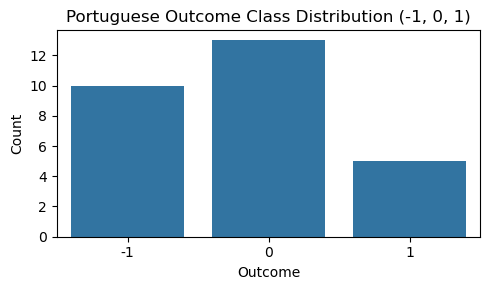

In [5]:
#Class Distribution
counts = y.value_counts().sort_index()
print("Outcome counts (label -> count):")
print(counts)

plt.figure(figsize=(5,3))
sns.barplot(x=counts.index.astype(str), y=counts.values)
plt.title("Portuguese Outcome Class Distribution (-1, 0, 1)")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [6]:
#Train/ Vaidation split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=random_state, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 21
Test size: 7


#### Models

In [7]:
#SVM
svm_clf = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=random_state)
)

#Multinomial Logistic Regression (with scaling)
log_clf = make_pipeline(
    StandardScaler(with_mean=False),
    LogisticRegression(multi_class='multinomial', solver='saga', max_iter=5000,
                       class_weight='balanced', random_state=random_state)
)

#Random Forest
rf_clf = RandomForestClassifier(n_estimators=300, random_state=random_state,
                                class_weight='balanced')

models = [("SVM", svm_clf), ("LogReg", log_clf), ("RF", rf_clf)]

~ SVM ~
Accuracy: 0.2857142857142857

Classification report:
               precision    recall  f1-score   support

          -1       0.33      0.33      0.33         3
           0       0.00      0.00      0.00         3
           1       0.50      1.00      0.67         1

    accuracy                           0.29         7
   macro avg       0.28      0.44      0.33         7
weighted avg       0.21      0.29      0.24         7



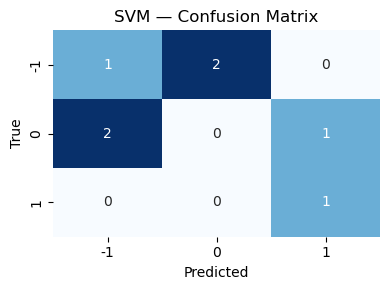

~ LogReg ~
Accuracy: 0.5714285714285714

Classification report:
               precision    recall  f1-score   support

          -1       0.60      1.00      0.75         3
           0       0.00      0.00      0.00         3
           1       0.50      1.00      0.67         1

    accuracy                           0.57         7
   macro avg       0.37      0.67      0.47         7
weighted avg       0.33      0.57      0.42         7



/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


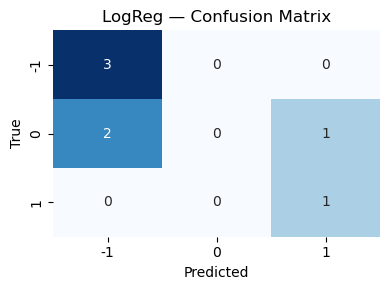

~ RF ~
Accuracy: 0.2857142857142857

Classification report:
               precision    recall  f1-score   support

          -1       0.50      0.33      0.40         3
           0       0.25      0.33      0.29         3
           1       0.00      0.00      0.00         1

    accuracy                           0.29         7
   macro avg       0.25      0.22      0.23         7
weighted avg       0.32      0.29      0.29         7



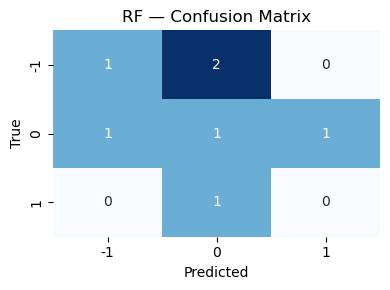

,Model,Accuracy
1,LogReg,0.571429
0,SVM,0.285714
2,RF,0.285714


In [8]:
#Train and evaluate
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print("~", name, "~")
    print("Accuracy:", acc)
    print("\nClassification report:\n", classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred, labels=[-1, 0, 1])
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['-1','0','1'], yticklabels=['-1','0','1'])
    plt.title(name + " — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
    return acc

results = []
for name, clf in models:
    acc = evaluate_model(name, clf, X_train, y_train, X_test, y_test)
    results.append((name, acc))

pd.DataFrame(results, columns=["Model","Accuracy"]).sort_values("Accuracy", ascending=False)

#### Summary and Interpretation

This exercise applied Support Vector Machines (SVM) to predict the Portuguese outcome of naval battles between 1583 and 1663 using the number of ships on each side and whether Spain was involved. The dataset included 28 battles with relatively few instances per outcome class (defeat = −1, draw = 0, victory = 1). Due to the small sample size and uneven distribution of outcomes, this problem was modeled as a multi-class classification task with class balancing.

The SVM model achieved an accuracy of ≈ 0.29, performing comparably to the Random Forest baseline and below the Logistic Regression model (≈ 0.57). SVM struggled to separate the classes effectively, especially the draws, likely due to limited data and overlapping numeric ranges between features. Logistic Regression performed better on the small sample, suggesting that the relationships among ship counts and outcomes may be mostly linear, while the Random Forest and SVM required more data to capture complex boundaries.

Confusion matrices revealed that all models tended to confuse draws (0) with defeats (−1), while victories (1) were rare but occasionally predicted correctly. This imbalance limits model reliability.

**Best model:** Logistic Regression (accuracy ≈ 57%)

**SVM and Random Forest:** Both reached about 29% accuracy, limited by small sample and overlapping feature space.

**Interpretation:** The relationship between ship counts and outcomes appears mostly linear, and the dataset’s small size reduces the benefit of more complex models like SVM or Random Forest.

In [9]:
#Predictions table on test
#re-fit all models on the full training set to ensure consistency
svm_clf.fit(X_train, y_train)
log_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

#Generate predictions
svm_preds = svm_clf.predict(X_test)
log_preds = log_clf.predict(X_test)
rf_preds = rf_clf.predict(X_test)

#Extract battles from the original dataframe based on test set index
battle_names = df.loc[X_test.index, 'battle']

#Build a combined DataFrame
comparison_table = pd.DataFrame({
    "Battle": battle_names.values,
    "Actual Outcome": y_test.values,
    "SVM Prediction": svm_preds,
    "LogReg Prediction": log_preds,
    "RF Prediction": rf_preds
})

#Show table 
comparison_table = comparison_table.sort_values("Battle").reset_index(drop=True)
comparison_table

,Battle,Actual Outcome,SVM Prediction,LogReg Prediction,RF Prediction
0,Goa,0,1,1,1
1,Goa,1,1,1,0
2,Hormuz,0,-1,-1,0
3,InvincibleArmada,-1,-1,-1,0
4,Jask,0,-1,-1,-1
5,MogincoalShoals,-1,0,-1,-1
6,Recife,-1,0,-1,0


In [10]:
#Predictions table on test
#Fit each model on the full dataset
svm_clf.fit(X, y)
log_clf.fit(X, y)
rf_clf.fit(X, y)

#Predict on the full dataset
svm_full_pred = svm_clf.predict(X)
log_full_pred = log_clf.predict(X)
rf_full_pred  = rf_clf.predict(X)

#Use battle names for all rows
all_battles = df.loc[X.index, 'battle']

#Build comparison table for full dataset
full_comparison = pd.DataFrame({
    "Battle": all_battles.values,
    "Actual Outcome": y.values,
    "SVM Prediction": svm_full_pred,
    "LogReg Prediction": log_full_pred,
    "RF Prediction": rf_full_pred
})

#Sort by battle name
full_comparison = full_comparison.sort_values("Battle").reset_index(drop=True)
full_comparison

,Battle,Actual Outcome,SVM Prediction,LogReg Prediction,RF Prediction
0,Abrolhos,0,0,1,0
1,Bahia,0,-1,-1,0
2,Bahia,-1,-1,-1,-1
3,Bahia,1,1,1,1
4,Bahia,-1,-1,-1,-1
5,Bantam,0,0,1,0
6,Colombo,1,0,1,1
7,Dunas,-1,-1,-1,-1
8,Dunas,0,0,1,0
9,Goa,0,0,1,0


#### **FINAL SUMMARY**
1. **Use an SVM model to predict the Portuguese outcome.**

An SVM classifier with an RBF kernel was trained using the number of Portuguese, Dutch, and English ships, along with Spanish involvement, to predict the Portuguese battle outcome (–1 = defeat, 0 = draw, 1 = victory). The SVM achieved ≈ 0.29 accuracy, correctly identifying some defeats and one victory but struggling especially with draws. The small dataset (28 battles) and overlapping numeric feature ranges limited the SVM’s ability to form meaningful nonlinear boundaries.

2. **Try solving the same problem using two other classifiers.**

Two comparison models were trained: Logistic Regression (a linear model) and Random Forest (a tree-based ensemble). Logistic Regression achieved the highest accuracy (≈ 0.57), while Random Forest matched the SVM (≈ 0.29). Logistic Regression handled the small dataset better, suggesting that the relationship between ship counts and battle outcomes is mostly linear, rather than highly nonlinear.

3. **Report and compare their results with those from SVM.**

Overall, Logistic Regression clearly outperformed SVM and Random Forest, correctly predicting more defeats and victories. All models struggled with draws, reflecting the dataset’s imbalance and limited size. SVM and Random Forest both misclassified most draws and made inconsistent predictions across battles, while Logistic Regression produced more stable predictions and higher recall for defeats and victories. These results reinforce that, for this dataset, simple linear structure aligns better with the underlying historical data than more complex boundary-based models like SVM or Random Forest.

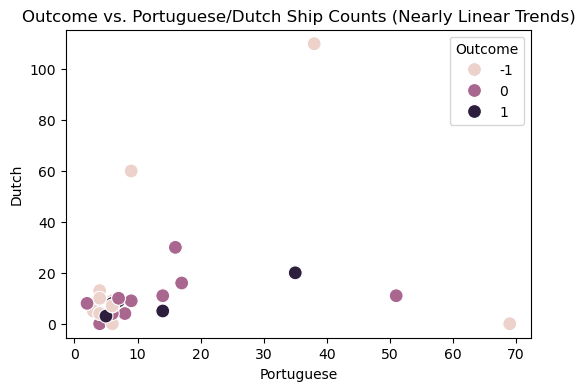

In [11]:
# Build a working copy with columns and outcomes
viz_df = df[[col_port, col_dutch, col_english, col_spanish, col_outcome]].copy()
viz_df = viz_df.rename(columns={
    col_port: "Portuguese",
    col_dutch: "Dutch",
    col_english: "English",
    col_spanish: "Spanish",
    col_outcome: "Outcome"
})

plt.figure(figsize=(6,4))
sns.scatterplot(data=viz_df, x="Portuguese", y="Dutch", hue="Outcome", s=100)
plt.title("Outcome vs. Portuguese/Dutch Ship Counts (Nearly Linear Trends)")
plt.show()

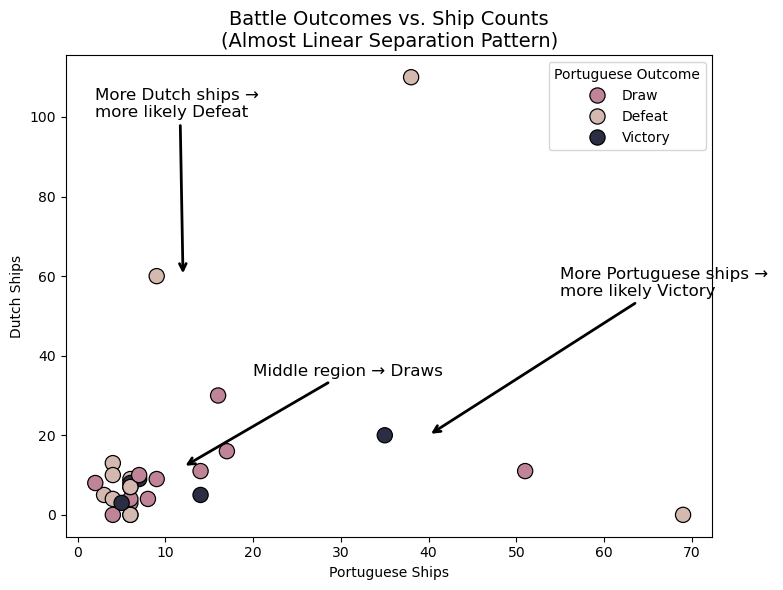

In [14]:
#Build annotated visual for clarity
viz_df2 = viz_df.copy()
viz_df2["Outcome Label"] = viz_df2["Outcome"].map({
    -1: "Defeat",
    0: "Draw",
    1: "Victory"
})

plt.figure(figsize=(8,6))

#Scatter plot
sns.scatterplot(
    data=viz_df2,
    x="Portuguese",
    y="Dutch",
    hue="Outcome Label",
    palette={"Defeat":"#d4b9b0", "Draw":"#c08497", "Victory":"#2b2d42"},
    s=120,
    edgecolor="black"
)

plt.title("Battle Outcomes vs. Ship Counts\n(Almost Linear Separation Pattern)", fontsize=14)
plt.xlabel("Portuguese Ships")
plt.ylabel("Dutch Ships")

#Add trend annotations
plt.annotate(
    "More Portuguese ships → \nmore likely Victory",
    xy=(40, 20),
    xytext=(55, 55),
    arrowprops=dict(arrowstyle="->", lw=2),
    fontsize=12
)

plt.annotate(
    "More Dutch ships → \nmore likely Defeat",
    xy=(12, 60),
    xytext=(2, 100),
    arrowprops=dict(arrowstyle="->", lw=2),
    fontsize=12
)

plt.annotate(
    "Middle region → Draws",
    xy=(12, 12),
    xytext=(20, 35),
    arrowprops=dict(arrowstyle="->", lw=2),
    fontsize=12
)

plt.legend(title="Portuguese Outcome")
plt.tight_layout()
plt.show()

##### Interpretation
Logistic Regression often performs well on classification problems, but its strong performance here is not because it is inherently “best” for classification in general. Instead, it performed best because the structure of this dataset matches the assumptions of Logistic Regression: the classes are separated in a mostly linear way based on ship counts. When the true decision boundary is close to linear, as the scatterplot shows, Logistic Regression naturally excels, even outperforming more flexible models like SVM and Random Forest, which require more data to capture complex patterns.